<a href="https://www.kaggle.com/code/riteshkumarweb/dbscan-clustering-algorithms?scriptVersionId=323547860" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# 📊 DBSCAN
# (Density-Based Spatial Clustering of Applications with Noise)

# DBSCAN is an Unsupervised Machine Learning algorithm

# 🎯 Goal:
# Group dense regions into clusters
# and identify outliers/noise automatically

# Unsupervised means:
# ❌ No target column (y)
# ✅ Only input features (X)


# 🧠 Idea:

# Points in high-density regions
# belong to the same cluster

# Points far away from clusters
# are considered Noise/Outliers


# 📦 Important Terms

# Core Point
# → Point having enough neighbors
# within a specified radius

# Border Point
# → Near a cluster but does not
# have enough neighbors itself

# Noise Point
# → Does not belong to any cluster
# (outlier)


# 📦 Important Hyperparameters

# eps
# → Radius around a point

# Example:
# eps = 0.5

# DBSCAN checks neighbors
# within distance 0.5


# min_samples
# → Minimum neighbors required
# to become a Core Point

# Example:
# min_samples = 5

# At least 5 nearby points needed


# 🔁 Working

# Step 1️⃣
# Pick a point

# Step 2️⃣
# Count neighbors within eps

# Step 3️⃣
# If neighbors >= min_samples
# → Core Point

# Step 4️⃣
# Expand cluster from Core Point

# Step 5️⃣
# Continue until all points processed

# Step 6️⃣
# Unconnected points become Noise


# 📊 Cluster Labels

# Cluster 1 → 0
# Cluster 2 → 1
# Cluster 3 → 2

# Noise Points → -1


# 📊 Finding Best eps

# Commonly use:
# K-Distance Plot

# Look for the "elbow point"
# in the graph


# ✅ Advantages

# No need to specify K clusters
# Automatically detects outliers
# Works well on irregular shapes
# Handles noise effectively

# ❌ Disadvantages

# Sensitive to eps selection
# Struggles with varying densities
# Performance drops in high dimensions


# 📊 Simple Diagram

#      🔵 🔵 🔵
#    🔵 🔵 🔵 🔵
#      🔵 🔵 🔵

#
#                     🟢 🟢 🟢
#                   🟢 🟢 🟢

#
#             ❌

# 🔵 → Cluster 1
# 🟢 → Cluster 2
# ❌ → Noise / Outlier


# 🧠 Difference from K-Means

# K-Means:
# → Uses Centroids 📍
# → Need K beforehand
# → Sensitive to outliers

# DBSCAN:
# → Uses Density 📊
# → No need for K
# → Detects outliers automatically
# → Works for irregular cluster shapes

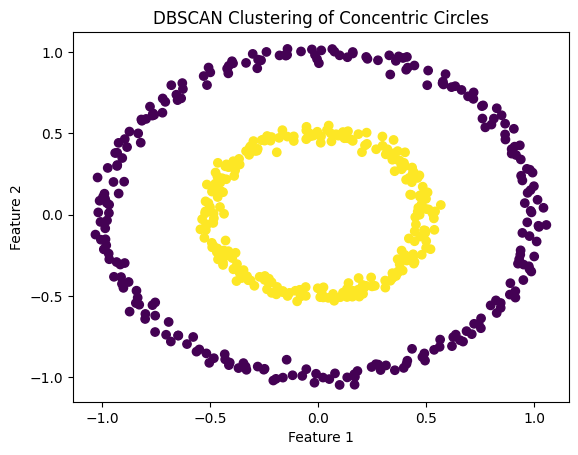

In [22]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
# Create concentric circle dataset
X,_ = make_circles(
    n_samples=500,  # Total number of data points
    noise=0.03,     # Add small random noise
    factor=0.5,      # Inner circle radius = 50% of outer circle
    random_state=4
)
# Create DBSCAN model
dbscan = DBSCAN(
    eps=0.1,        # Neighborhood radius
    min_samples=5   # Minimum points needed to form a dense region
)
clusters = dbscan.fit_predict(X)# Train DBSCAN and get cluster labelsD
# Plot data points and color them by cluster
plt.scatter(
    X[:, 0],        # Feature 1 (X-axis)
    X[:, 1],        # Feature 2 (Y-axis)
    c=clusters,     # Color according to cluster labels
    cmap='viridis'  # Color map
)
plt.title("DBSCAN Clustering of Concentric Circles")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()